In [1]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


# podział na zbiór testowy i walidacyjny

In [19]:
df_cleaned = df_retu

In [29]:
df_retu.columns

Index(['Season', 'Channel', 'STCL', 'ClearanceWeek', 'RETU', 'Subclass',
       'SLSU', 'PriceDiffFromLastRegular', 'StockCalculationDate',
       'Last2DaysSLSU', 'Last3DaysSLSU', 'Last4DaysSLSU', 'Last5DaysSLSU',
       'BeforeClearanceSeasonSLSU', 'Last2WeeksBeforeClearanceSLSU',
       'SbclSLSULY', 'FabricComposition', 'Line', 'PredictionsSLSU',
       'RETU_Regular'],
      dtype='object')

In [20]:
X_test = df_cleaned[df_cleaned['Season'] == "AW 2023"]
X_walid = df_cleaned[df_cleaned['Season'] == "SS 2023"]
X_train = df_cleaned[(df_cleaned['Season'] != "SS 2023") & (df_cleaned['Season'] != "AW 2023")]


In [94]:
zmienna_zależna = "RETU"
zmienne_niezależne = ["ClearanceWeek", 'Last5DaysSLSU', 'StockCalculationDate']

In [95]:
X_train_data = X_train[zmienne_niezależne]
y_train = X_train[zmienna_zależna]

X_walid_data = X_walid[zmienne_niezależne]
y_walid = X_walid[zmienna_zależna]

X_test_data = X_test[zmienne_niezależne]
y_test = X_test[zmienna_zależna]


# model

In [91]:
X_train_data.isnull().sum()

ClearanceWeek           0
Last5DaysSLSU           0
StockCalculationDate    0
dtype: int64

In [92]:
model = LinearRegression()
model.fit(X_train_data, y_train)

y_walid_pred = model.predict(X_walid_data)
y_test_pred = model.predict(X_test_data)

In [93]:
print("Wyniki na zbiorze walidacyjnym:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_walid, y_walid_pred):.2f}")
print(f"Współczynnik R^2: {r2_score(y_walid, y_walid_pred):.2f}")

print("\nWyniki na zbiorze testowym:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_test_pred):.2f}")
print(f"Współczynnik R^2: {r2_score(y_test, y_test_pred):.2f}")


Wyniki na zbiorze walidacyjnym:
Mean Squared Error (MSE): 298.95
Współczynnik R^2: 0.05

Wyniki na zbiorze testowym:
Mean Squared Error (MSE): 420.03
Współczynnik R^2: 0.05


In [88]:
coefficients = pd.DataFrame({
    "Variable": zmienne_niezależne,
    "Coefficient": model.coef_
})
print("\nWspółczynniki regresji liniowej:")
print(coefficients)

#wyrazu wolnego
print(f"\nWyraz wolny: {model.intercept_:.2f}")



Współczynniki regresji liniowej:
        Variable  Coefficient
0  ClearanceWeek     1.595727
1  Last5DaysSLSU    -0.000001

Wyraz wolny: -21.83


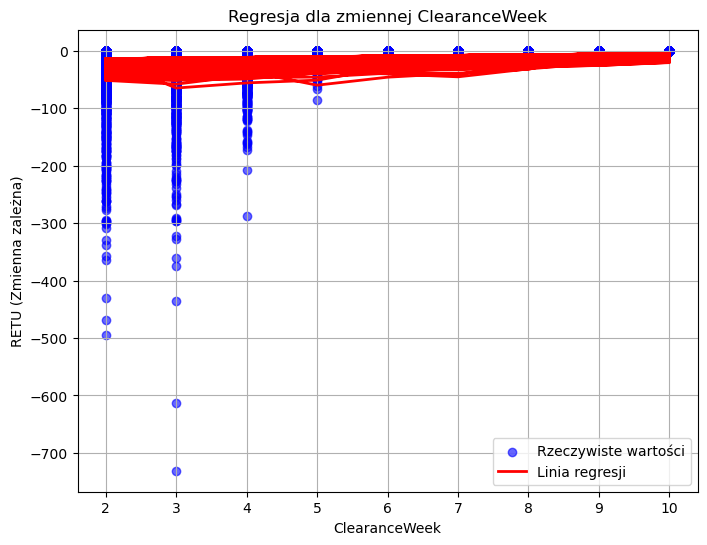

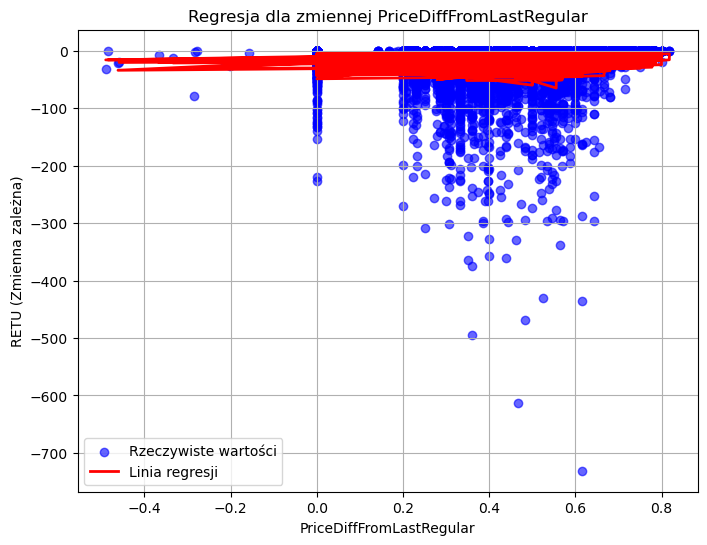

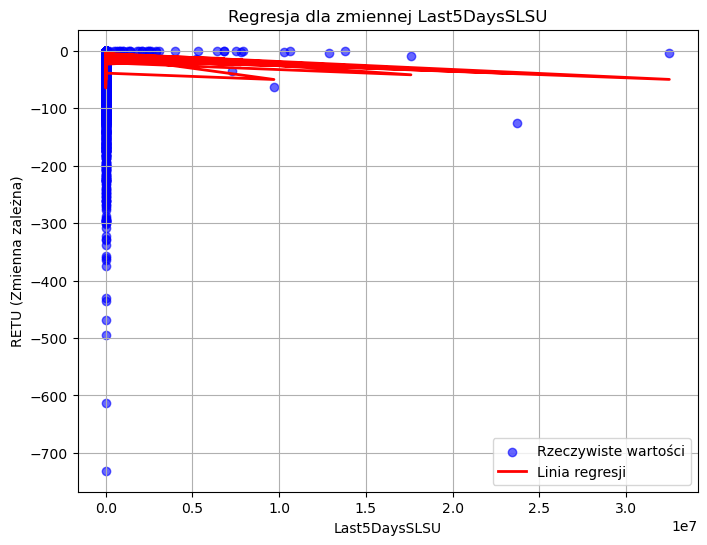

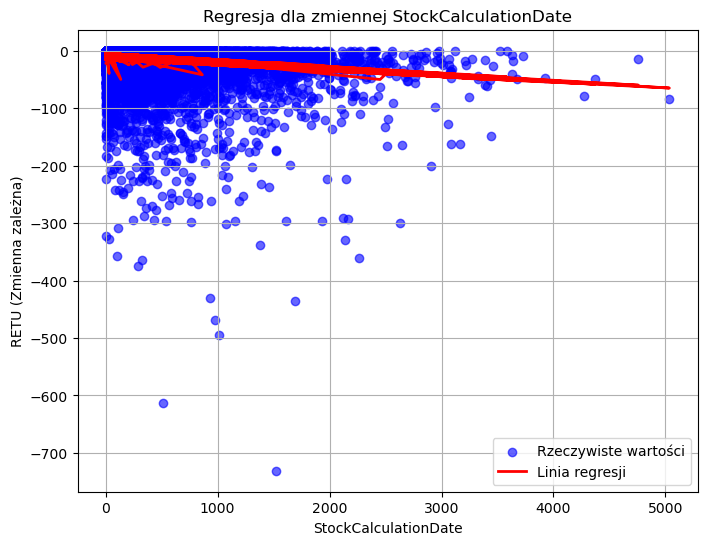

In [48]:
for feature in zmienne_niezależne:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_test_data[feature], y_test, color="blue", alpha=0.6, label="Rzeczywiste wartości")
    plt.plot(
        X_test_data[feature],
        model.predict(X_test_data),
        color="red",
        linewidth=2,
        label="Linia regresji"
    )
    plt.xlabel(feature)
    plt.ylabel("RETU (Zmienna zależna)")
    plt.title(f"Regresja dla zmiennej {feature}")
    plt.legend()
    plt.grid(True)
    plt.show()

# kodowanie zmiennych kategorycznych

In [ ]:
X_test.describe(include=['object'])

In [ ]:
def OneHotEncode(X_train, X_test, encoded_column_name, **encoder_kwargs):
    
    ohe = OneHotEncoder(**encoder_kwargs)
    ohe.fit(X_train[encoded_column_name].values.reshape(-1, 1))
    transformed_train = ohe.transform(X_train[encoded_column_name].values.reshape(-1, 1))
    transformed_test = ohe.transform(X_test[encoded_column_name].values.reshape(-1, 1))
    
    column_names = [encoded_column_name +"_"+category for category in list(ohe.categories_[0]) ]
    df_transformed_train = pd.DataFrame(transformed_train, columns = column_names)
    df_transformed_test = pd.DataFrame(transformed_test, columns = column_names)
    
    df_out_train = X_train.reset_index(drop=True).drop([encoded_column_name], axis=1)
    df_out_test = X_test.reset_index(drop=True).drop([encoded_column_name], axis=1)
    df_out_train = pd.concat([df_out_train, df_transformed_train],axis=1)
    df_out_test = pd.concat([df_out_test, df_transformed_test],axis=1)
    
    return df_out_train, df_out_test

In [ ]:
X_train_ohe1, X_test_ohe1 = OneHotEncode(X_train, X_test, "Channel", handle_unknown="ignore",sparse_output=False)
X_train_ohe, X_test_ohe = OneHotEncode(X_train_ohe1, X_test_ohe1, "Line", handle_unknown="ignore",sparse_output=False)
#X_walid_ohe2, X_test_ohe2 = OneHotEncode(X_train_ohe, X_test_ohe, "Subclass", handle_unknown="ignore",sparse_output=False)
X_test_ohe.head()